# Retail Sales Analysis

## Project Overview

This project analyzes retail sales data to understand customer shopping behavior,
sales trends, product category performance, customer demographics, and purchasing patterns.

### Objectives

- Analyze monthly and quarterly sales trends
- Understand customer demographics
- Identify top-performing product categories
- Analyze quantity and spending patterns
- Identify important business insights
- Provide actionable business recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows and Columns: (1000, 9)

Columns:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## 2. Descriptive Statistics

In [4]:
df .describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0


In [7]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

In [8]:
# Dataset ka size
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types aur missing values ki basic information
print("\nDataset Information:")
df.info()

Rows and Columns: (1000, 10)

Columns:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Month']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   period[M]     
dtypes: datetime64[ns](1), int64(5), object(3), per

## 2. Descriptive Statistics

In [9]:
# Descriptive statistics for numerical columns
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


## 3. Data Cleaning

In [10]:
# Convert Date column from text to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check the result
print(df['Date'].dtype)

# Show first 5 dates
df[['Date']].head()

datetime64[ns]


,Date
0,2023-11-24
1,2023-02-27
2,2023-01-13
3,2023-05-21
4,2023-05-06


In [11]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Month               0
dtype: int64

Duplicate Rows: 0


## 4. Sales Trend Analysis

In [12]:
# Create Month column
df['Month'] = df['Date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Display monthly sales
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

## 5. Customer Demographics Analysis

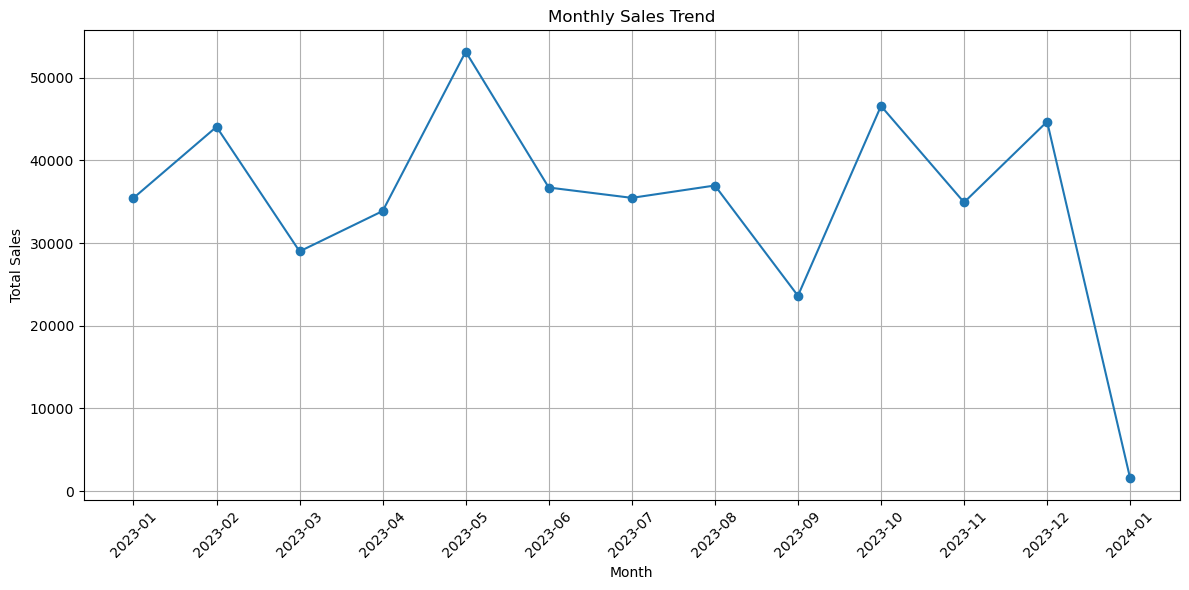

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

Sales varied across the months, with the highest monthly sales recorded in May 2023.
Sales were comparatively lower in September 2023 and January 2024.

In [14]:
# Create Quarter column
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate quarterly sales
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

# Display quarterly sales
quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

### Observation

Quarterly sales show variations across the year, indicating changes in overall sales performance between different quarters.
The highest sales were observed in the quarter containing May 2023.

In [15]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [16]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

age_group_sales

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-64     80410
Name: Total Amount, dtype: int64

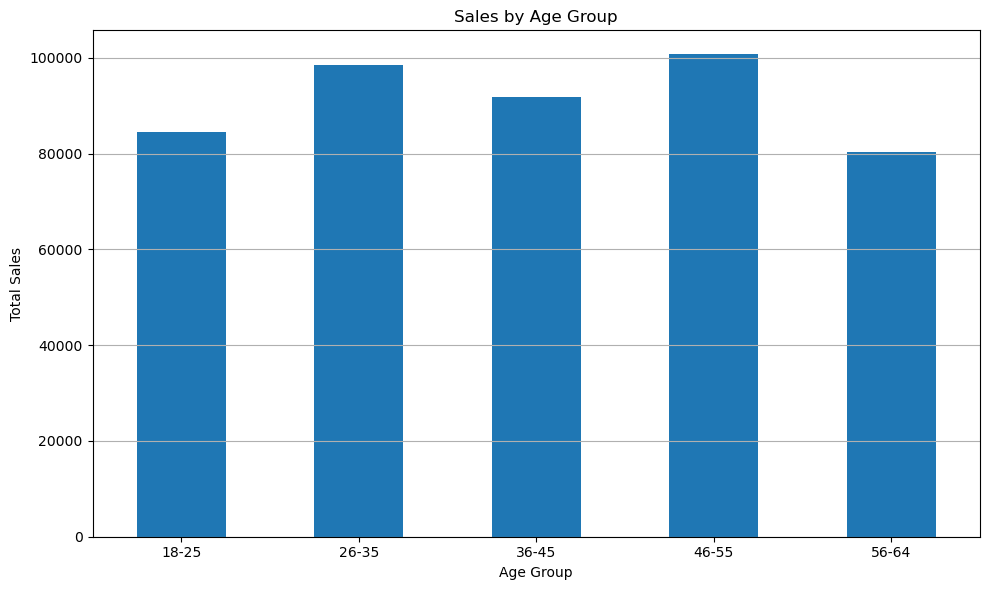

In [17]:
plt.figure(figsize=(10, 6))

age_group_sales.plot(kind='bar')

plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Observation

Customers aged 46-55 generated the highest total sales among all age groups.
The 56-64 age group generated the lowest sales compared with the other age groups.

In [18]:
# Sales by Product Category
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

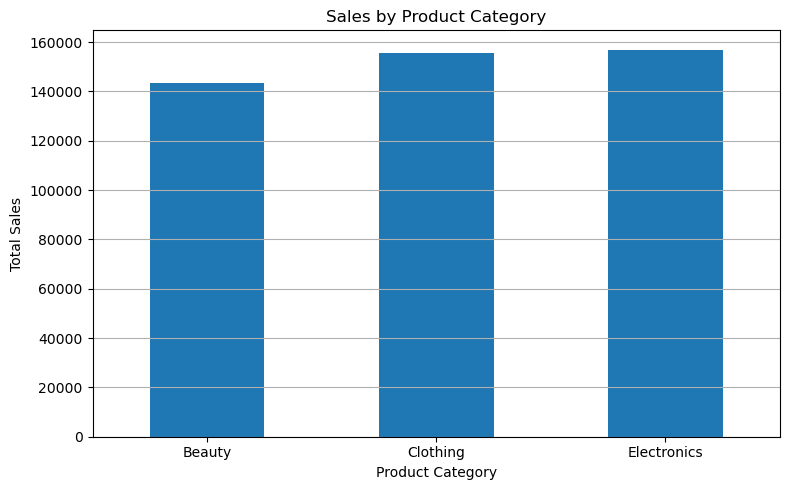

In [19]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Observation

Electronics generated the highest total sales among the three product categories.
Clothing and Beauty also contributed significantly to the overall revenue.

## 6. Product Category Analysis

### Dataset Limitation

The dataset does not contain individual product names, so a Top 10 best-selling product analysis cannot be performed.
Therefore, product performance is analyzed using Product Category based on total revenue and quantity sold.

In [20]:
# Quantity sold by product category
category_quantity = df.groupby('Product Category')['Quantity'].sum()

category_quantity

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

In [21]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

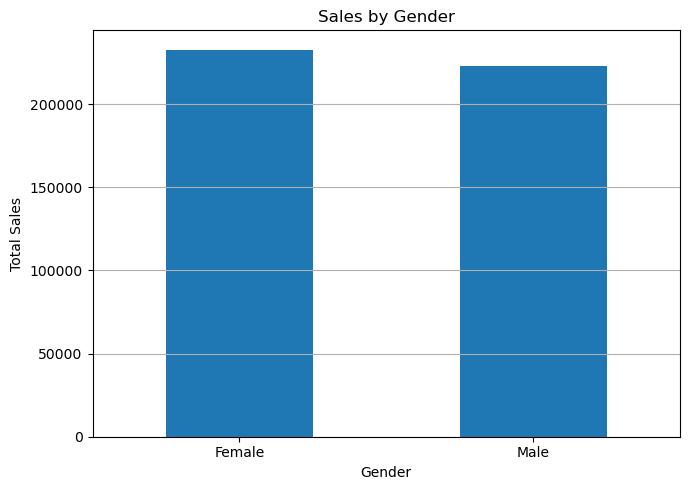

In [22]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Observation

Female customers generated slightly higher total sales than male customers.
This shows that female customers contributed a little more to the overall revenue

## 7. Customer Spending & Behavior Analysis

In [23]:
avg_gender_spending = df.groupby('Gender')['Total Amount'].mean()

avg_gender_spending

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

In [24]:
correlation = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


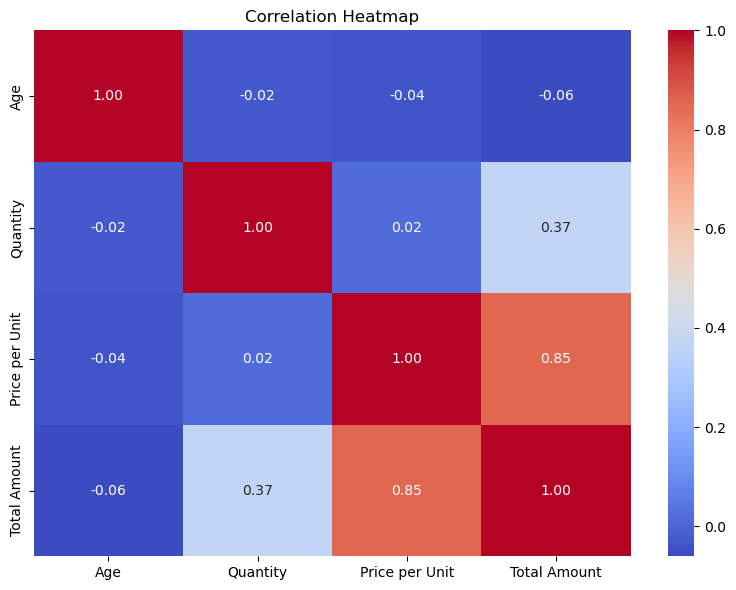

In [25]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

Price per Unit has a strong positive correlation with Total Amount.
Quantity also has a positive relationship with Total Amount, while Age has very little correlation with sales.

In [26]:
customer_sales = df.groupby('Customer ID')['Total Amount'].sum()

top_customers = customer_sales.sort_values(ascending=False).head(10)

top_customers

Customer ID
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
CUST089    2000
CUST946    2000
CUST157    2000
CUST155    2000
CUST420    2000
Name: Total Amount, dtype: int64

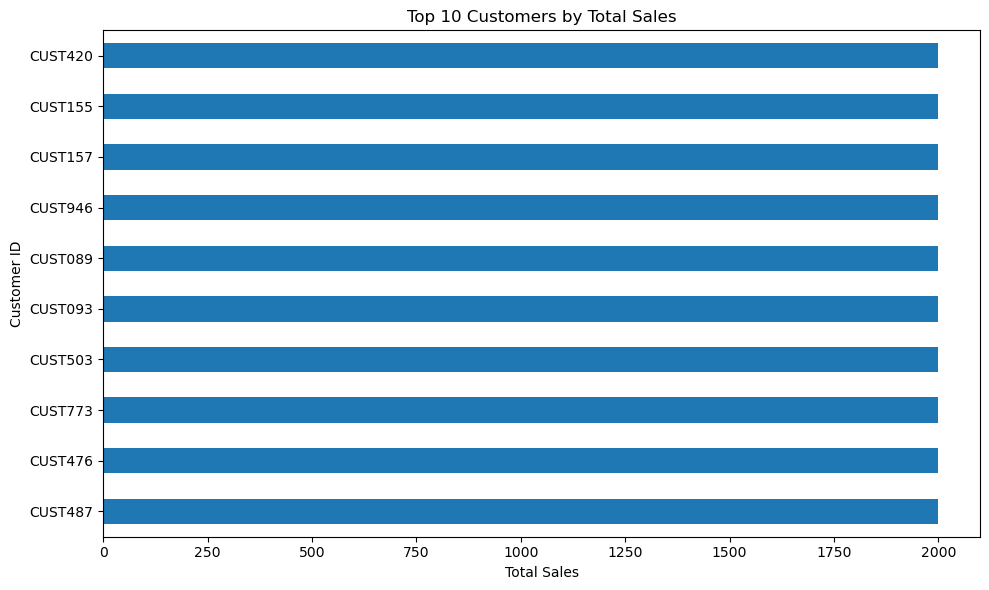

In [27]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

### Observation

The top 10 customers generated relatively high total sales compared with other individual customers.
However, each customer appears only once in the dataset, so customer retention and repeat purchases cannot be analyzed from this dataset.

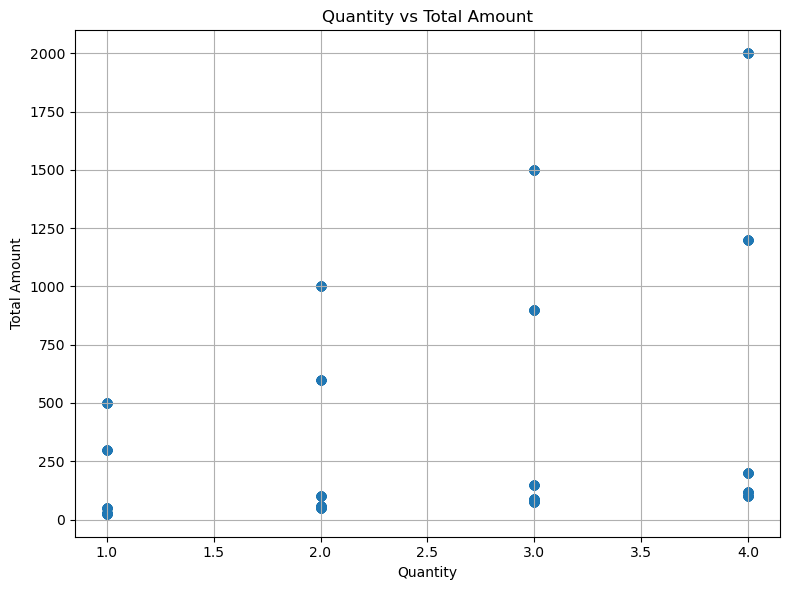

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(df['Quantity'], df['Total Amount'])

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a positive relationship between Quantity and Total Amount.
Transactions with higher quantities generally tend to have higher total amounts.

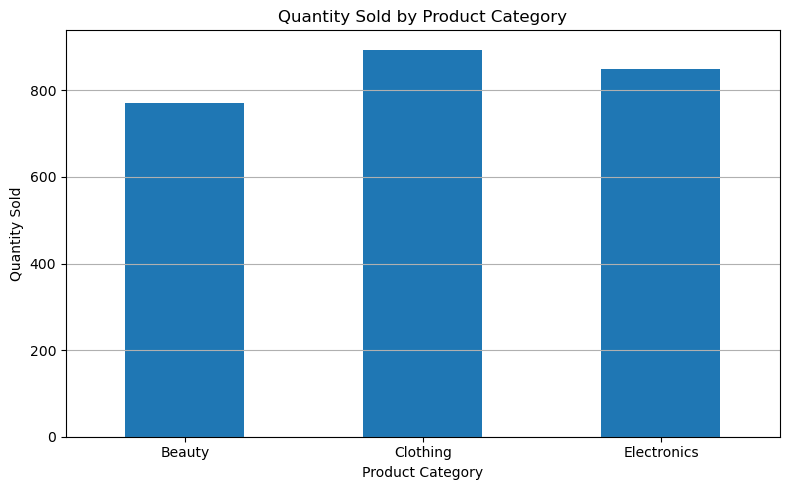

In [29]:
plt.figure(figsize=(8, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Observation

Clothing had the highest quantity sold among all product categories.
Beauty had the lowest quantity sold, while Electronics showed moderate sales volume.

In [30]:
customer_frequency = df.groupby('Customer ID')['Transaction ID'].count()

print("Total Unique Customers:", customer_frequency.count())
print("Customers with More Than 1 Purchase:", (customer_frequency > 1).sum())
print("Customers with Only 1 Purchase:", (customer_frequency == 1).sum())

Total Unique Customers: 1000
Customers with More Than 1 Purchase: 0
Customers with Only 1 Purchase: 1000


## 8. Final Business Insights

In [31]:
print("FINAL BUSINESS INSIGHTS")
print("------------------------")

print("1. Highest Sales Category:", category_sales.idxmax())
print("2. Highest Sales Category Amount:", category_sales.max())

print("3. Highest Quantity Category:", category_quantity.idxmax())
print("4. Highest Quantity Sold:", category_quantity.max())

print("5. Highest Sales Age Group:", age_group_sales.idxmax())
print("6. Highest Age Group Sales:", age_group_sales.max())

print("7. Highest Sales Month:", monthly_sales.idxmax())
print("8. Highest Monthly Sales:", monthly_sales.max())

print("9. Female Total Sales:", gender_sales['Female'])
print("10. Male Total Sales:", gender_sales['Male'])

FINAL BUSINESS INSIGHTS
------------------------
1. Highest Sales Category: Electronics
2. Highest Sales Category Amount: 156905
3. Highest Quantity Category: Clothing
4. Highest Quantity Sold: 894
5. Highest Sales Age Group: 46-55
6. Highest Age Group Sales: 100690
7. Highest Sales Month: 2023-05
8. Highest Monthly Sales: 53150
9. Female Total Sales: 232840
10. Male Total Sales: 223160


## 9. Business Recommendations

In [32]:
print("BUSINESS RECOMMENDATIONS")
print("-----------------------")

print("1. Focus more on Electronics because it generated the highest sales.")
print("2. Promote Clothing products because Clothing had the highest quantity sold.")
print("3. Target customers aged 46-55 because this age group generated the highest sales.")
print("4. Study the factors behind the high sales in May 2023 and plan similar campaigns.")
print("5. Female customers generated slightly higher total sales, so targeted promotions can be considered.")
print("6. Since every customer has only one transaction, customer retention and repeat-purchase campaigns can be introduced.")

BUSINESS RECOMMENDATIONS
-----------------------
1. Focus more on Electronics because it generated the highest sales.
2. Promote Clothing products because Clothing had the highest quantity sold.
3. Target customers aged 46-55 because this age group generated the highest sales.
4. Study the factors behind the high sales in May 2023 and plan similar campaigns.
5. Female customers generated slightly higher total sales, so targeted promotions can be considered.
6. Since every customer has only one transaction, customer retention and repeat-purchase campaigns can be introduced.


In [33]:
numerical_columns = df.select_dtypes(include='number').columns

statistics = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


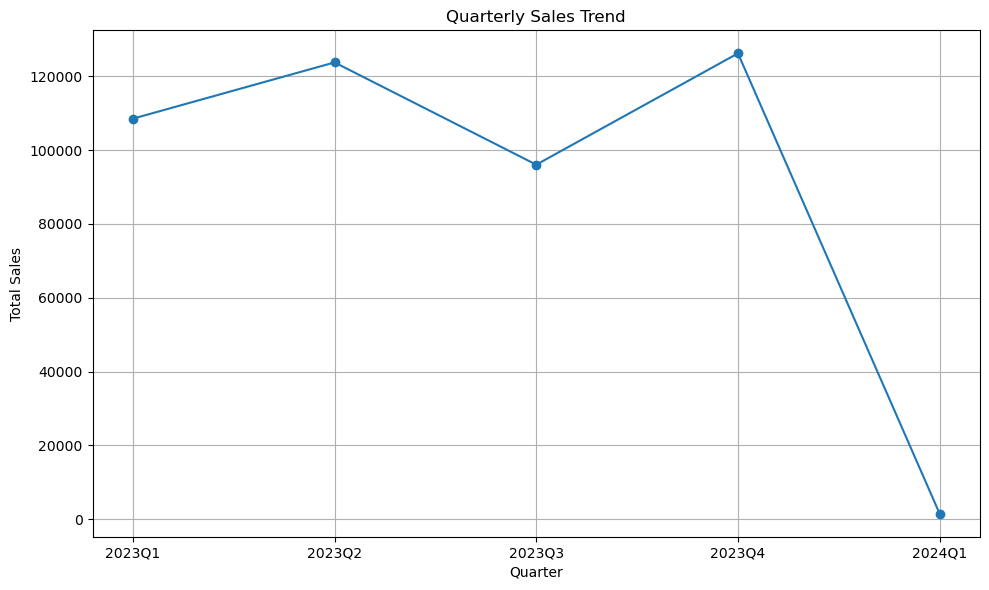

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Quarterly sales show variations across the year, indicating changes in overall sales performance between different quarters.
The highest sales were observed in the quarter containing May 2023.